In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from utils.pde import PDE
from utils.triangulation import Triangulation
from utils.finite_element import LagrangeBasis, FiniteElement
from utils.tensor_network import TensorUnit, TensorNetwork
from utils.solver import DMRG

In [2]:
r = [0, 0.01]

In [3]:
def avg_diff(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

In [4]:
step = 100

x = np.linspace(0, 1, step)
x_step = 1/step
y0 = np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)


def d2(u):
    u = np.concatenate([np.array(u[:1]), u,np.array(u[-1:])])
    return (u[2:] + u[:-2] + -2*u[1:-1])/x_step ** 2

def dxdxu(t, u):
    return d2(u)

y = solve_ivp(dxdxu, r, y0, t_eval = np.array(r[-1:]))#, rtol = 1e-20, atol = 1e-10)

In [5]:
Bs = [0, 1, 2, 3, 4, 5]
deltas = [0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]
steps = [int(r[-1]/delta) for delta in deltas]

In [6]:
pde_dxdxu_txt = 'D[2, 0, 0]'
pde_dxdxu = PDE(pde_dxdxu_txt, equal_time_derivative = True)

continuity_order = 1
bond_order = 1
rounds = 10
alpha = 1

In [7]:
out = []

elements = 5
for basis_order in Bs:
    print(basis_order)
    out_delta = []
    for delta, n_steps in zip(deltas, steps):
        print('\t'+ str(delta))
        triangulation = Triangulation(np.linspace(0, 1, elements + 1))
        basis = LagrangeBasis(1, basis_order)

        fe = FiniteElement(triangulation, basis)
        fe.set_con_bc_operators(continuity_order)
        fe.set_env_bc_operators({0: {1: ([np.array([[0]]), np.array([[[1]]])], 
                                        np.array([[0]]))},
                                elements - 1: {0: ([np.array([[0]]), np.array([[[1]]])], 
                                        np.array([[0]]))}})

        fe.calculate_higher_domain_derivatives(2)

        tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)
        tn.set_u_shape(tuple())
        tn.set_h_tensor_units([])

        y0 = lambda x: np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)
        rep = fe.fun2rep(y0)
        rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
        states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

        all_reps = [[states.tensor[..., 0, 0].copy()]]
        for reps, pde in zip(all_reps, [pde_dxdxu]):
            for i in range(int(n_steps)):
                pde_operators, pde_power =  tn.get_operators_from_pde(pde.pde, delta, states.copy())
                tn.set_states(states, bond_order)
                tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
                tn.set_solver(DMRG())
                tn.set_operators(pde_operators, pde_power)
                states = tn.solve(rounds = rounds, alpha = alpha, env = True)
                reps.append(states.tensor[..., 0, 0].copy())
            states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

        out_delta.append(avg_diff(fe.rep2fun(all_reps[-1][-1])(x), y.y[..., -1]))
    out.append(out_delta)


0
	0.01
	0.005
	0.002


d:\projects\TNPDE\utils\finite_element.py:440: RuntimeWarning: invalid value encountered in divide
  d_con_bc_operators.append(domain_side_derivatives/norm)
d:\projects\TNPDE\utils\finite_element.py:441: RuntimeWarning: invalid value encountered in divide
  n_con_bc_operators.append(neighbor_side_derivatives/norm)


	0.001
	0.0005
	0.0002
	0.0001
1
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
2
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
3
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
4
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
5
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001


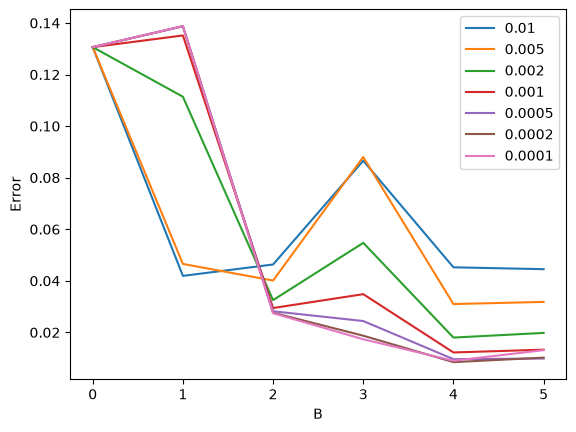

In [15]:
out = np.array(out).T
for o, delta in zip(out, deltas):
    plt.plot(Bs, o, label = f'{delta}')

plt.xlabel('B')
plt.ylabel('Error')
plt.legend()
plt.show()

In [16]:
tmp = np.array([[0.13062669, 0.0419191 , 0.04633286, 0.08656823, 0.04523925,
        0.04451499],
       [0.13062669, 0.04655005, 0.04010236, 0.0880217 , 0.03099307,
        0.03182281],
       [0.13062669, 0.11139071, 0.03251179, 0.05471848, 0.01799251,
        0.01979405],
       [0.13062669, 0.13515493, 0.02944836, 0.03482391, 0.0122164 ,
        0.01329857],
       [0.13062669, 0.13870745, 0.02819064, 0.02440514, 0.00961551,
        0.00986379],
       [0.13062669, 0.13876694, 0.02762301, 0.01871745, 0.00846016,
        0.01020412],
       [0.13062669, 0.13876694, 0.02744478, 0.01732853, 0.00900357,
        0.01310771]])

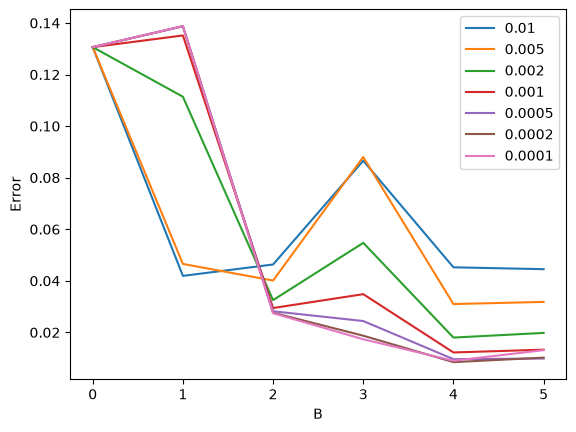

In [17]:
for o, delta in zip(tmp, deltas):
    plt.plot(Bs, o, label = f'{delta}')

plt.xlabel('B')
plt.ylabel('Error')
plt.legend()
plt.show()